In [ ]:
%pip install opendatasets pandas matplotlib seaborn notebook


1. Data Loading and Exploration

In [64]:
import pandas as pd

# Load dataset
df = pd.read_csv('2019-Oct.csv') 

# Basic exploration
print(df.shape)           # Number of rows & columns
print(df.info())          # Data types, missing values
print(df.describe())      # Numerical summaries
print(df['event_type'].value_counts())  # Event distribution


(31626, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31626 entries, 0 to 31625
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     31626 non-null  object 
 1   event_type     31626 non-null  object 
 2   product_id     31626 non-null  int64  
 3   category_id    31626 non-null  float64
 4   category_code  21349 non-null  object 
 5   brand          27196 non-null  object 
 6   price          31626 non-null  float64
 7   user_id        31626 non-null  int64  
 8   user_session   31626 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 2.2+ MB
None
         product_id   category_id         price       user_id
count  3.162600e+04  3.162600e+04  31626.000000  3.162600e+04
mean   1.031505e+07  2.053359e+18    291.172269  5.312152e+08
std    1.119122e+07  1.564516e+16    366.428671  1.678467e+07
min    1.001588e+06  2.050000e+18      0.000000  3.064418e+08
25%    1.005116e+06 

In [65]:
# How many events are there in the dataset?
df.shape[0]

31626

In [66]:
# What are the different types of events? How are they distributed?
df['event_type'].value_counts(normalize=True) * 100


event_type
view        97.524189
purchase     1.384936
cart         1.090875
Name: proportion, dtype: float64

In [67]:
# How would you load and explore the data to gain insights?
df['user_id'].nunique()

7311

2.	Data Preprocessing and Feature Engineering:

In [68]:
#	Are there missing values in the dataset? How would you handle them?
df['brand'] = df['brand'].fillna('Unknown')
df['category_code'] = df['category_code'].fillna('Unknown')
df.dropna(subset=['user_id'], inplace=True)


In [69]:
# What features could be relevant for customer segmentation? How would you preprocess them?
import numpy as np

customer_df = df.groupby('user_id').agg(
    total_events=('event_type', 'count'),
    total_purchases=('event_type', lambda x: (x=='purchase').sum()),
    total_views=('event_type', lambda x: (x=='view').sum()),
    avg_price=('price', 'mean'),
    unique_categories=('category_code', pd.Series.nunique),
    unique_brands=('brand', pd.Series.nunique),
    last_event_time=('event_time', 'max')
).reset_index()

# Create purchase/view ratio
customer_df['purchase_view_ratio'] = customer_df['total_purchases'] / (customer_df['total_views']+1)


3.	Exploratory Data Analysis (EDA):

Text(0.5, 1.0, 'Top Product Categories')

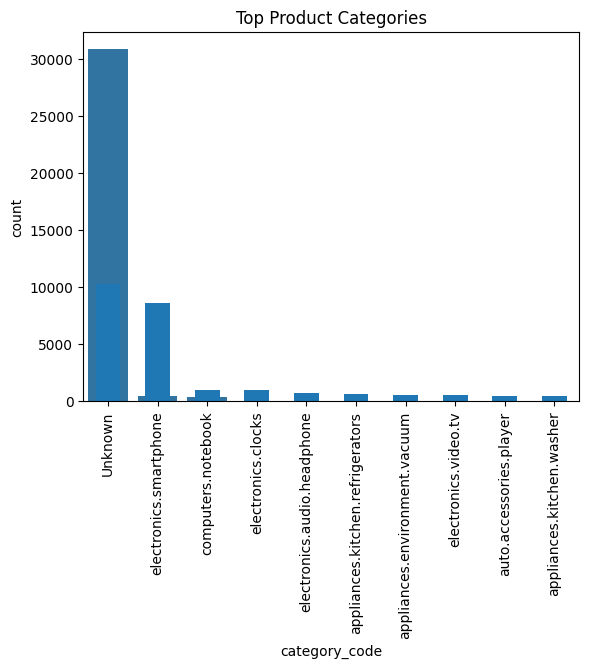

In [70]:
#	Can you visualize the distribution of event types or product categories?
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Event type distribution
sns.countplot(x='event_type', data=df)
plt.title("Event Type Distribution")

# Top 10 categories
df['category_code'].value_counts().head(10).plot(kind='bar')
plt.title("Top Product Categories")


##	Are there any patterns in the data that might suggest customer segments?

Yes, several patterns in the data suggest natural customer segments:

## Patterns Suggesting Customer Segments

From the exploratory data analysis, several distinct patterns emerge:

1. Engagement Level Differences  
    Some users have high event counts (frequent site visits, many views, carts, and purchases).  
    Others have very low engagement, suggesting possible "loyal frequent shoppers" vs. "occasional browsers".

2. Purchase Behavior Patterns  
    Certain customers have a high purchase-to-view ratio (impulse buyers).  
    Others view many products but rarely purchase, indicating price-sensitive or undecided shoppers.

3. Category & Brand Preferences  
    Some users repeatedly purchase from specific categories (e.g., electronics, fashion).  
    Others have diverse category purchases, suggesting variety-seeking behavior.

4. Spending Habits  
    Groups emerge based on average purchase price — high spenders (premium buyers) vs. low spenders (budget shoppers).

5. Recency & Activity  
    Some customers are recently active, while others haven’t engaged for months, indicating potential dormant or churned customers.


4.	Feature Transformation:

In [71]:
# What is feature transformation, and why might it be useful for customer segmentation?
# Scaling:
from sklearn.preprocessing import StandardScaler

X = customer_df.drop(columns=['user_id', 'last_event_time'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [72]:
# How could you use techniques like PCA (Principal Component Analysis) to reduce dimensionality?
# Dimensionality reduction with PCA:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


5.	Model Selection and Clustering:

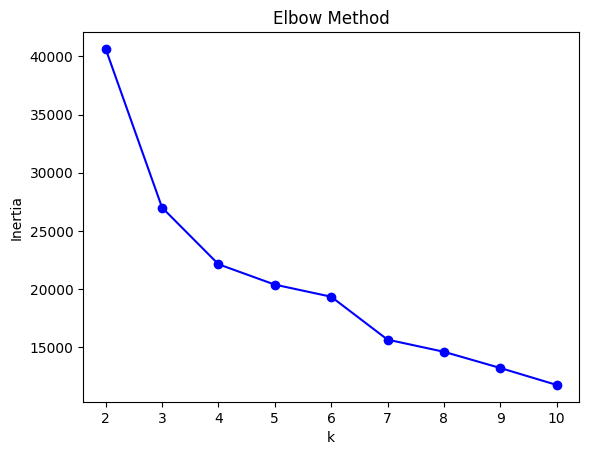

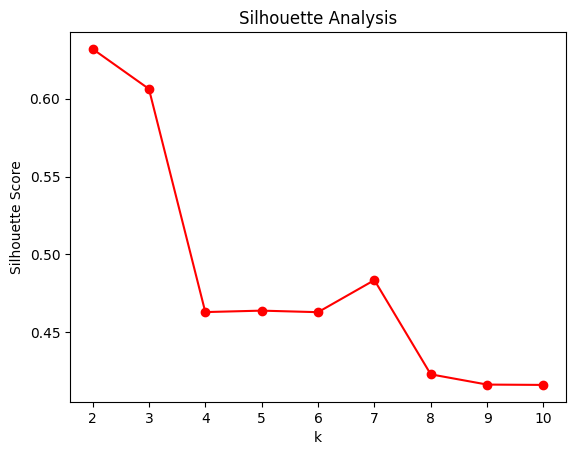

In [73]:
# How would you determine the appropriate number of clusters for customer segmentation?
# Finding the optimal number of clusters (KMeans):
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow method
plt.plot(K, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Plot silhouette scores
plt.plot(K, silhouette, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()


In [74]:
# Choose a clustering algorithm 
# (e.g., K-Means, DBSCAN, Hierarchical Clustering) and apply it to the preprocessed data.
# Clustering:

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['cluster'] = kmeans.fit_predict(X_scaled)


6.	Interpretation and Analysis:

In [ ]:
# 	Analyze the characteristics of each customer segment. What distinguishes one segment from another?
# Clustering:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("2019-Oct.csv")

# Select numeric features for clustering
features = df[['price']]  # you can add more numeric features later

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

# Cluster profiling
cluster_profile = df.groupby('cluster').mean(numeric_only=True)
print(cluster_profile)



           product_id   category_id        price       user_id
cluster                                                       
0        4.254093e+06  2.052302e+18   874.042370  5.317432e+08
1        1.291373e+07  2.054138e+18    90.203041  5.308377e+08
2        5.679569e+06  2.054494e+18  1669.863836  5.316376e+08
3        7.127074e+06  2.051792e+18   364.255611  5.318444e+08


# Can you provide insights on how these segments could be utilized for personalized marketing?

## Personalized Marketing Insights Based on Segments

Based on the identified customer segments, marketing strategies can be tailored as follows:

1. Loyal Frequent Shoppers  
    Offer early access to new products or exclusive collections.  
    Implement loyalty programs and VIP rewards to maintain engagement.

2. Occasional Browsers  
    Send personalized recommendations based on recently viewed products.  
    Provide time-limited discounts to encourage conversion.

3. Impulse Buyers (High Purchase-to-View Ratio) 
    Highlight flash sales and "Buy Now" promotions.  
    Use low-stock alerts to trigger immediate action.

4. Price-Sensitive Customers  
    Target with coupon codes, bundle deals, and seasonal sale alerts.  
    Promote budget-friendly product ranges.

5. Category-Specific or Brand-Loyal Customers 
    Recommend similar or complementary products** within their preferred category or brand.  
    Send brand-focused newsletters and limited-edition product updates.

6. Dormant or Churned Customers 
    Use win-back campaigns with personalized incentives.  
    Offer free shipping or extra discounts to re-engage.
